**Wine Quality Dataset**

We will compare the use of a logistic regression model using a single feature vs. the use of a logistic regression model using multiple features to predict the color/hue of a wine in a dataset.

Start by combining the datasets for red and white wine into one big dataset.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# load separate dataframes
dfr = pd.read_csv("winequality-red.csv", delimiter=";")
dfw = pd.read_csv("winequality-white.csv", delimiter=";")

# hue of graph
dfr['hue'] = 0
dfw['hue'] = 1

# put both types of wine into one dataset
df_wine = pd.concat([dfr, dfw], ignore_index = True)

# print full dataframe
print(df_wine)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free sulfur dioxide  

We'll check the correlation in order to decide which feature is most relevant to train the model on.

<Axes: >

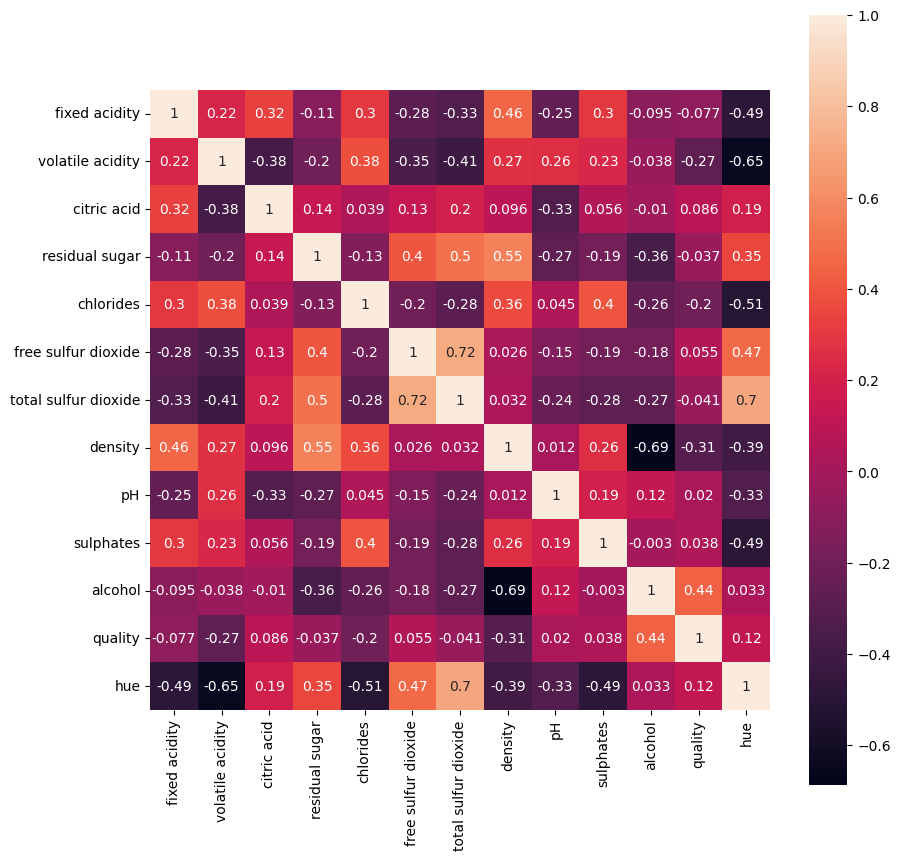

In [5]:
correlation = df_wine.corr(method='pearson')

fig = plt.gcf()

fig.set_size_inches(10,10)

sns.heatmap(correlation, annot = True,square = True)

Visually, we can see that the largest correlation between a feature and the hue is 0.7 for total sulfur dioxide.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

X = df_wine[['total sulfur dioxide']]
y = df_wine['hue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(random_state = 0)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Accuracy score: " + str(accuracy_score(y_test, y_pred)))
print("\nConfusion matrix: \n" + str(confusion_matrix(y_test, y_pred)))
print("\nClassification report: \n" + str(classification_report(y_test, y_pred)))

Accuracy score: 0.9184149184149184

Confusion matrix: 
[[ 439  118]
 [  57 1531]]

Classification report: 
              precision    recall  f1-score   support

           0       0.89      0.79      0.83       557
           1       0.93      0.96      0.95      1588

    accuracy                           0.92      2145
   macro avg       0.91      0.88      0.89      2145
weighted avg       0.92      0.92      0.92      2145



To check the multiple feature regression, we can just take out the "quality" feature since it is subjective and not a physical quantity.

In [10]:
X = df_wine.drop(['quality', 'hue'], axis=1)
y = df_wine['hue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(random_state = 0)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Accuracy score: " + str(accuracy_score(y_test, y_pred)))
print("\nConfusion matrix: \n" + str(confusion_matrix(y_test, y_pred)))
print("\nClassification report: \n" + str(classification_report(y_test, y_pred)))

Accuracy score: 0.9888111888111888

Confusion matrix: 
[[ 544   13]
 [  11 1577]]

Classification report: 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       557
           1       0.99      0.99      0.99      1588

    accuracy                           0.99      2145
   macro avg       0.99      0.98      0.99      2145
weighted avg       0.99      0.99      0.99      2145



Clearly, we can see that multiple features works better.